# Results of recording and subject LOO for binary classification for individual emotions

In [46]:
import os 
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
from pathlib import Path

# Path to a run folder, relative to project root
RUN_DIR_REL = Path('results/binary/2026-03-04_13-46-24')
SUMMARY_FILE = 'summary.csv'
DECISION_THRESHOLD = 0.5
MODELS_FOR_CM = ['GNN','Mean','SVM','LightGBM','MLP']  # any subset of ['GNN','Mean','SVM','LightGBM','MLP']

# Resolve robustly from notebook cwd by walking up parent dirs
search_bases = [Path.cwd(), *Path.cwd().parents]
run_candidates = [base / RUN_DIR_REL for base in search_bases]
RUN_DIR = next((p for p in run_candidates if p.exists()), None)

if RUN_DIR is None:
    tried = '\n'.join(str(p) for p in run_candidates)
    raise FileNotFoundError(
        f'Run directory not found for {RUN_DIR_REL}. Tried:\n{tried}'
    )

strategy_dirs = sorted([p for p in RUN_DIR.iterdir() if p.is_dir() and (p / SUMMARY_FILE).exists()])
strategies = [p.name for p in strategy_dirs]

if not strategies:
    raise RuntimeError(f'No strategy folders with {SUMMARY_FILE} found under {RUN_DIR}')

FIGURES_DIR = RUN_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig: plt.Figure, filename: str) -> Path:
    """Save a Matplotlib figure under RUN_DIR_REL/figures and return its path."""
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f'Saved figure: {output_path}')
    return output_path

print(f'Run: {RUN_DIR}')
print(f'Strategies: {strategies}')
print(f'Figures directory: {FIGURES_DIR}')


Run: /home/ppg/eyetracking/GFM-for-eyetracker/results/binary/2026-03-04_13-46-24
Strategies: ['recording_loo']
Figures directory: /home/ppg/eyetracking/GFM-for-eyetracker/results/binary/2026-03-04_13-46-24/figures


## Load results

In [48]:
all_results = []

for strategy_dir in strategy_dirs:
    path = strategy_dir / SUMMARY_FILE
    df = pd.read_csv(path)
    if 'metric_type' in df.columns:
        df = df[df['metric_type'] != 'aggregated']
    df['strategy'] = strategy_dir.name
    df['run'] = RUN_DIR.name
    all_results.append(df)

if not all_results:
    raise RuntimeError('No summary data loaded.')

results_df = pd.concat(all_results, ignore_index=True)
try:
    display(results_df.head())
except NameError:
    print(results_df.head())


,model,metric_type,accuracy,precision,recall,f1,auc,strategy,run
0,Mean,emotion_emotion-predictability,0.572493,0.572493,1.000000,0.685872,0.425000,recording_loo,2026-03-04_13-46-24
1,SVM,emotion_emotion-predictability,0.523956,0.569850,0.842274,0.628064,0.393816,recording_loo,2026-03-04_13-46-24
2,LightGBM,emotion_emotion-predictability,0.496146,0.555371,0.695519,0.569890,0.395106,recording_loo,2026-03-04_13-46-24
3,MLP,emotion_emotion-predictability,0.527260,0.575175,0.685866,0.578237,0.398685,recording_loo,2026-03-04_13-46-24
4,GNN,emotion_emotion-predictability,0.559081,0.574298,0.806888,0.629143,0.415883,recording_loo,2026-03-04_13-46-24


## Plot 

Saved figure: /home/ppg/eyetracking/GFM-for-eyetracker/results/binary/2026-03-04_13-46-24/figures/metrics_barplots.png


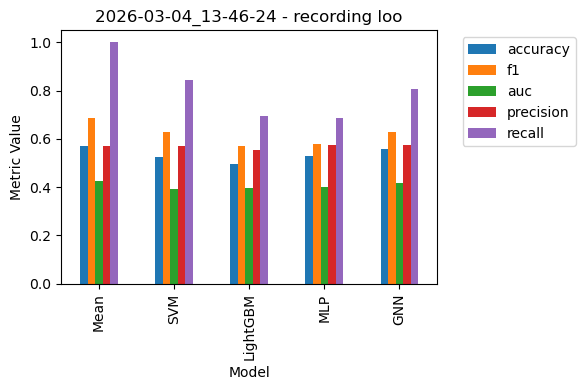

In [49]:
candidate_metrics = ['accuracy', 'f1', 'auc', 'precision', 'recall']
plot_metrics = [m for m in candidate_metrics if m in results_df.columns]

if not plot_metrics:
    raise RuntimeError('No metric columns found to plot.')

fig, axes = plt.subplots(1, len(strategies), figsize=(6 * len(strategies), 4), sharey=True)
if len(strategies) == 1:
    axes = [axes]

for ax, strategy in zip(axes, strategies):
    subdir_results = results_df[results_df['strategy'] == strategy]
    if subdir_results.empty:
        ax.set_axis_off()
        ax.set_title(f'{strategy} (no data)')
        continue

    subdir_results.plot(x='model', y=plot_metrics, kind='bar', ax=ax)
    ax.set_title(f"{RUN_DIR.name} - {strategy.replace('_', ' ')}")
    ax.set_xlabel('Model')
    ax.set_ylabel('Metric Value')
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
save_figure(fig, 'metrics_barplots.png')
plt.show()


## Confusion matrices

Saved figure: /home/ppg/eyetracking/GFM-for-eyetracker/results/binary/2026-03-04_13-46-24/figures/confusion_matrices.png


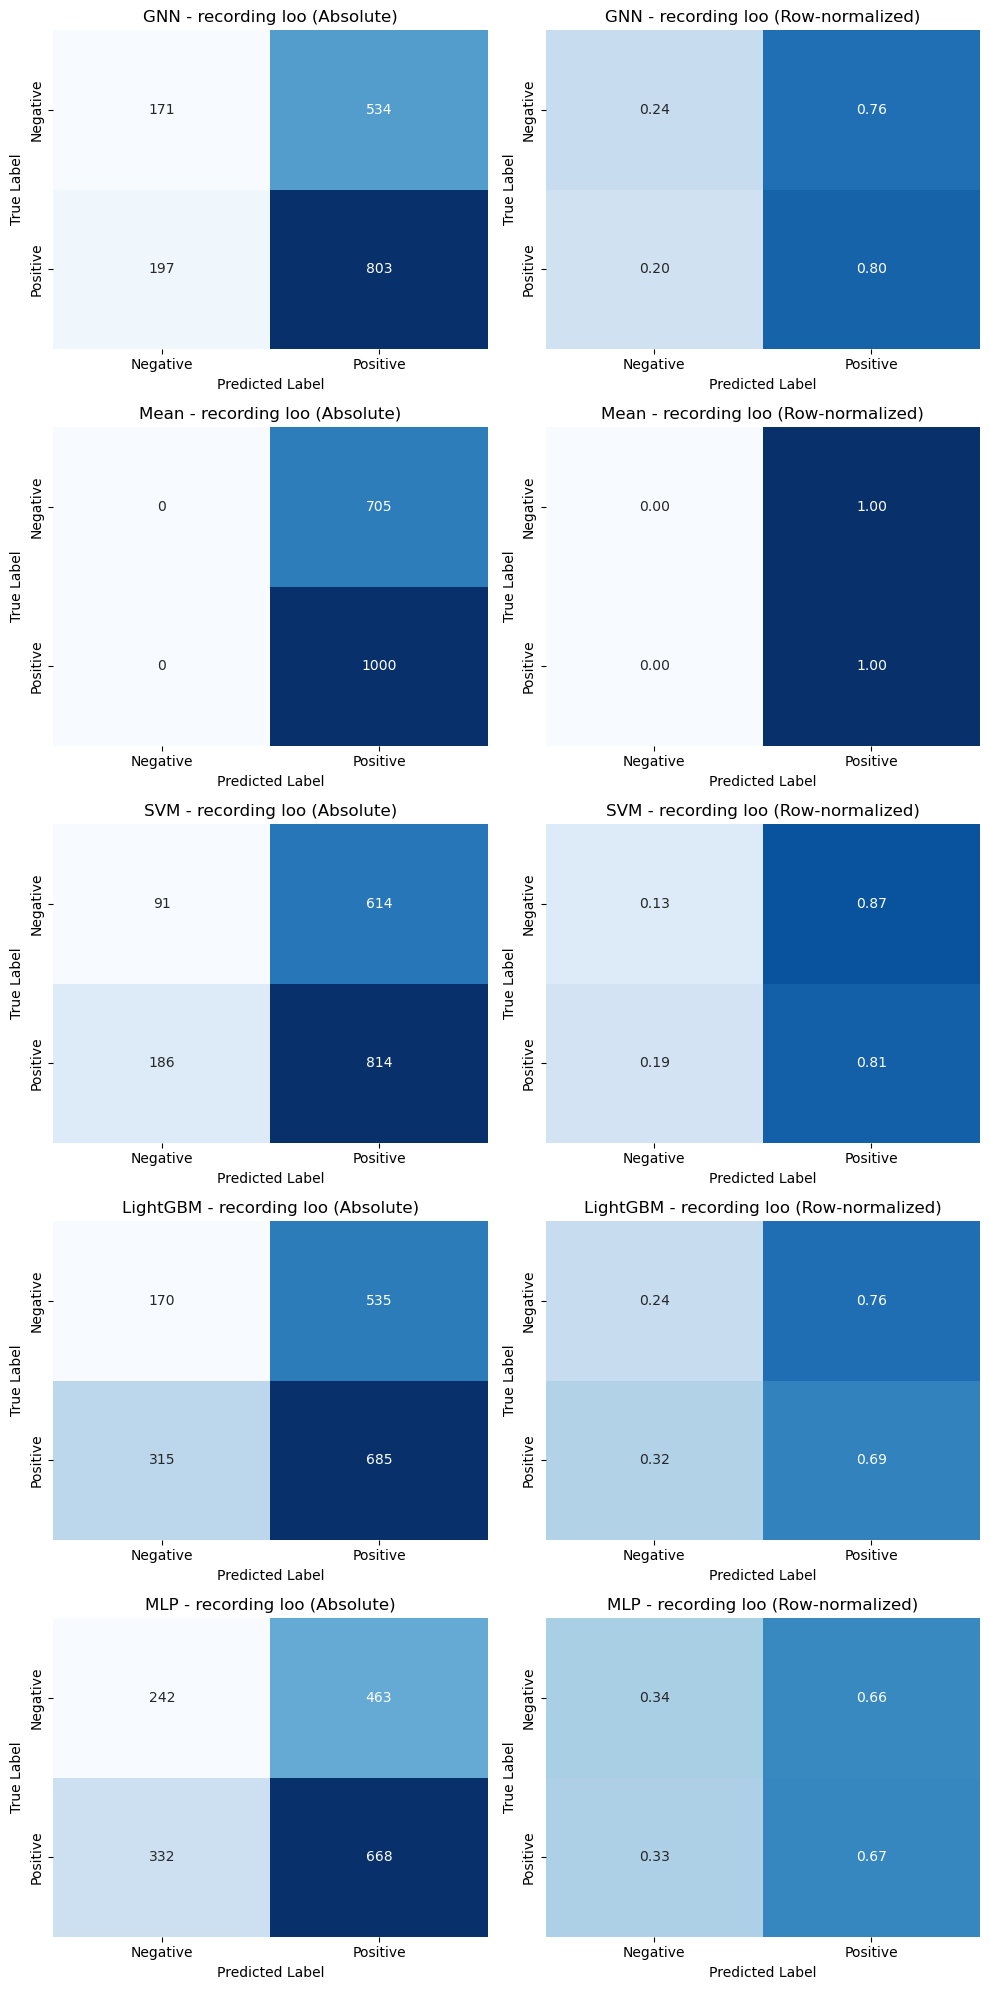

In [50]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

n_models = len(MODELS_FOR_CM)
n_strategies = len(strategies)
n_cols = 2 * n_strategies  # Absolute + row-normalized for each strategy
fig, axes = plt.subplots(n_models, n_cols, figsize=(5 * n_cols, 4 * n_models))

# Normalize axes indexing for 1D cases
if n_models == 1:
    axes = np.array([axes])

for row_idx, model_name in enumerate(MODELS_FOR_CM):
    for strategy_idx, strategy in enumerate(strategies):
        abs_ax = axes[row_idx, 2 * strategy_idx]
        rel_ax = axes[row_idx, 2 * strategy_idx + 1]
        strategy_path = RUN_DIR / strategy
        fold_dirs = sorted([p for p in strategy_path.iterdir() if p.is_dir()])

        all_predictions = []
        all_targets = []

        for fold_dir in fold_dirs:
            if model_name == 'GNN':
                pred_path = fold_dir / 'test_predictions.npy'
                target_path = fold_dir / 'test_targets.npy'
            else:
                pred_path = fold_dir / 'baselines' / model_name / 'test_predictions.npy'
                target_path = fold_dir / 'baselines' / model_name / 'test_targets.npy'

            if pred_path.exists() and target_path.exists():
                preds = np.asarray(np.load(pred_path)).reshape(-1)
                targets = np.asarray(np.load(target_path)).reshape(-1)
                all_predictions.append(preds)
                all_targets.append(targets)

        if all_predictions and all_targets:
            all_predictions = np.concatenate(all_predictions)
            all_targets = np.concatenate(all_targets).astype(int)
            pred_classes = (all_predictions >= DECISION_THRESHOLD).astype(int)

            cm = confusion_matrix(all_targets, pred_classes, labels=[0, 1])
            row_sums = cm.sum(axis=1, keepdims=True)
            cm_row_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

            sns.heatmap(
                cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                cbar=False,
                ax=abs_ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
            )
            abs_ax.set_xlabel('Predicted Label')
            abs_ax.set_ylabel('True Label')
            abs_ax.set_title(f"{model_name} - {strategy.replace('_', ' ')} (Absolute)")

            sns.heatmap(
                cm_row_norm,
                annot=True,
                fmt='.2f',
                cmap='Blues',
                vmin=0.0,
                vmax=1.0,
                cbar=False,
                ax=rel_ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
            )
            rel_ax.set_xlabel('Predicted Label')
            rel_ax.set_ylabel('True Label')
            rel_ax.set_title(f"{model_name} - {strategy.replace('_', ' ')} (Row-normalized)")
        else:
            abs_ax.set_axis_off()
            rel_ax.set_axis_off()
            abs_ax.set_title(f"{model_name} - {strategy} (no prediction files)")
            rel_ax.set_title(f"{model_name} - {strategy} (no prediction files)")

plt.tight_layout()
save_figure(fig, 'confusion_matrices.png')
plt.show()

